In [2]:
import pandas as pd
import numpy as np
from sklearn.experimental import enable_iterative_imputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer
from sklearn.linear_model import LinearRegression, BayesianRidge
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV
import shap

In [3]:
import warnings
warnings.filterwarnings("ignore")

In [4]:
def trans_donnees(X):
    X1 = X.copy()
    
    # Suppression des variables avec trop de valeurs manquantes (>50%)
    X1.drop(columns=[
        'Numero_Conteneur_Entree', 'Salle_Balance_Entree', 'Region_Entree', 'IP_Entree',
        'Numero_Conteneur_Sortie', 'ID_Balance_Sortie', 'Region_Sortie', 'IP_Sortie',
        'Routine_Manutention', 'Numero_Sequence', 'Remarque', 'Annule', 'Annule_Par', 'Date_Annulation'
    ], inplace=True, errors='ignore')
    
    # Suppression des identifiants inutiles (aucune valeur prédictive)
    X1.drop(columns=[
        'Numero_Camion', 'Plaque_Camion', 'ID_Cargaison',
        'Connaissement', 'Numero_Marque', 'Numero_Pesee', 'Voyage', 'Statut'
    ], inplace=True, errors='ignore')
    
    # Suppression des doublons
    X1 = X1.drop_duplicates()
    
    # Suppression valeurs aberrantes (variables quantitatives)
    X1.loc[X1['Poids_Cargaison_kg'] > 100000, 'Poids_Cargaison_kg'] = np.nan
    X1.loc[X1['Poids_Tare_kg'] > 100000, 'Poids_Tare_kg'] = np.nan
    X1.loc[X1['Poids_Camion_Entree_kg'] > 100000, 'Poids_Camion_Entree_kg'] = np.nan
    
    # Seuil surestarie — 10 000 min (~7 jours)
    X1.loc[X1['Surestarie_min'] > 10000, 'Surestarie_min'] = np.nan
    X1.loc[X1['Surestarie_min'] < 0, 'Surestarie_min'] = np.nan
    
    # Suppression variables redondantes et inutiles
    X1.drop(columns=[
        'Poids_Brut_Camion_kg',
        'Poids_Camion_Sortie_kg'  
    ], inplace=True, errors='ignore')
    
    # Suppression des lignes sans variable cible
    X1.dropna(subset=['Surestarie_min'], inplace=True)
    
    # Transformation logarithmique
    # ✅ Poids_Camion_Sortie_kg remplacé par Poids_Camion_Entree_kg
    log_vars = ['Surestarie_min', 'Poids_Tare_kg',
                'Poids_Cargaison_kg', 'Poids_Camion_Entree_kg']
    for var in log_vars:
        X1[f'log_{var}'] = np.log1p(X1[var])
    
    # Suppression du log de la cible (pas une feature)
    X1.drop(columns=['log_Surestarie_min'], inplace=True)
    
    # Feature engineering temporel
    X1['Heure_Entree_Gate'] = pd.to_datetime(X1['Heure_Entree_Gate'], format='%d/%m/%Y %H:%M')
    X1['Heure_Sortie_Gate'] = pd.to_datetime(X1['Heure_Sortie_Gate'], format='%d/%m/%Y %H:%M')
    
    X1['heure_entree'] = X1['Heure_Entree_Gate'].dt.hour
    X1['jour_semaine'] = X1['Heure_Entree_Gate'].dt.dayofweek
    X1['mois']         = X1['Heure_Entree_Gate'].dt.month
    
    X1.drop(columns=['Heure_Entree_Gate', 'Heure_Sortie_Gate'], inplace=True)
    
    # Typage des variables qualitatives
    var_quali = ['Nom_Cargaison', 'Nom_Navire', 'Operateur_Entree', 
                 'Operateur_Sortie', 'Type_Travail']
    for var in var_quali:
        X1[var] = X1[var].astype('object')
    
    return X1

In [5]:
train = pd.read_csv('C:/Users/LENOVO/Documents/Stage_DMP/port-ai-project/data/train.csv', index_col=0)
print(train.shape)
print(train.head())
print(train.columns)

(25498, 34)
         Numero_Camion Plaque_Camion ID_Cargaison   Connaissement  \
Statut                                                              
Gate-out    WDJB911D61     DJB911D61  DC240305005               2   
Gate-out  VCH042677500   CH042677500  DC240219002       TABUK0001   
Gate-out  VCH043848864   CH043848864  DC230909091   NSSCB23002351   
Gate-out     WETA18383      ETA18383  DC240224088  HK23170XDBT016   
Gate-out     WETA22810      ETA22810  DC240505007  NJ2401LYGDJ202   

                                   Numero_Marque  Nom_Cargaison   Nom_Navire  \
Statut                                                                         
Gate-out                      MILLINGWHEATINBULK          Wheat  BOS BOUTROS   
Gate-out                       JTMAA7BJ4P4063170        Vehicle  BAHRI TABUK   
Gate-out                       RKLKABAG3P0509459        Vehicle      JIGJIGA   
Gate-out  CCCC-FHECETHIOPIAEAHPROJECTVIADJIBOUTI         *Rebar     HELENA K   
Gate-out          BELTCO

In [6]:
train = trans_donnees(train)
X_train = train.drop(['Surestarie_min'], axis=1)
y_train = train['Surestarie_min']

In [7]:
val = pd.read_csv('C:/Users/LENOVO/Documents/Stage_DMP/port-ai-project/data/validation.csv', index_col=0)
print(val.head())

         Numero_Camion Plaque_Camion ID_Cargaison   Connaissement  \
Statut                                                              
Gate-out    WDJB288D62     DJB288D62  DC240214010   SSMCB24000009   
Gate-out      WET88021       ET88021  DC240114020   SSMCB24000002   
Gate-out  VCH042736646   CH042736646  DC240224043  HK23170LDBT044   
Gate-out     WETA10211      ETA10211  DC240123018   SSMCB24000005   
Gate-out     WET526D67      ET526D67  DC231121003        MZDDJI01   

                             Numero_Marque Nom_Cargaison    Nom_Navire Voyage  \
Statut                                                                          
Gate-out                    NPSBFERTILIZER    Fertilizer        ZURICH  12024   
Gate-out                    NPSBFERTILIZER    Fertilizer        SABAEK  04L23   
Gate-out                 LZZ5ELSC8PN256285       Vehicle      HELENA K  23170   
Gate-out                     NPSFERTILIZER    Fertilizer       CORINNA     49   
Gate-out  NONALLOYSTEELBILLETS

In [8]:
val = trans_donnees(val)
X_val = val.drop(['Surestarie_min'], axis=1)
y_val = val['Surestarie_min']

In [9]:
var_quali = ['Nom_Cargaison', 'Nom_Navire', 'Operateur_Entree', 
             'Operateur_Sortie', 'Type_Travail']

var_quanti = ['Poids_Tare_kg', 'Poids_Cargaison_kg', 
              'Poids_Camion_Entree_kg',          
              'heure_entree', 'jour_semaine', 'mois',
              'log_Poids_Tare_kg', 'log_Poids_Cargaison_kg', 
              'log_Poids_Camion_Entree_kg']       

# sans Surestarie_min puisque c'est la variable à prédire
var_moy = ['Poids_Tare_kg', 'Poids_Camion_Entree_kg', 
           'heure_entree', 'jour_semaine', 'mois']

var_med = ['Poids_Cargaison_kg', 'Poids_Camion_Entree_kg',  
           'log_Poids_Tare_kg', 'log_Poids_Cargaison_kg', 
           'log_Poids_Camion_Entree_kg']                     

### Imputation Simple

In [13]:
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy="most_frequent")),
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
])#permet d'enchainer les deux sur la même variable
preprocessor_simple = ColumnTransformer([#chaque ligne est indpendante, impératif qu'une variable ne passe que dans une ligne
    ('num_med', SimpleImputer(strategy="median"), var_med),
    ('num_moy', SimpleImputer(strategy="mean"), var_moy),
    ('cat', cat_pipeline, var_quali)#comme deux lignes sur les quali=> un pipeline qui englobe les deux lignes
])
pipe_simple_arbre = Pipeline([
    ('comp', preprocessor_simple),
    ('arbre', DecisionTreeRegressor())
])

In [14]:
#Entrainement
pipe_simple_arbre.fit(X_train, y_train)
#prediction sur train
y_pred_train = pipe_simple_arbre.predict(X_train)
#prediction sur test
y_pred_val = pipe_simple_arbre.predict(X_val)

In [15]:
def qualite_reg(y, y_pred):
    mse = mean_squared_error(y, y_pred)
    print("MSE:", mse)
    print("RMSE", np.sqrt(mse))
    print("R²:", r2_score(y, y_pred))
    print("MAE", mean_absolute_error(y, y_pred))

In [16]:
#résultat obtenus en apprentissage
print("apprentissage")
qualite_reg(y_train, y_pred_train)
#résultat obtenus en validation
print('validation')
qualite_reg(y_val, y_pred_val)
#très gros surapprentissage!
#important d'ajouter des hyperparamètres

apprentissage
MSE: 24635.619223140537
RMSE 156.9573802761136
R²: 0.9695271653514483
MAE 18.657802672455947
validation
MSE: 462516.6364072627
RMSE 680.0857566566607
R²: 0.3598520493361489
MAE 286.99481383513654


In [13]:
param_grid = { 
    'arbre__max_depth': [3, 5, 7, 10], #bien pensé que le nom indique avant les __ correspond au nom ds le pipeline qui fait ref à la méthode
    'arbre__min_samples_split': [25, 50, 35]} 

In [14]:
grid = GridSearchCV( 
    estimator=pipe_simple_arbre, 
    param_grid=param_grid, 
    cv=5, 
    scoring='neg_mean_squared_error', 
    n_jobs=-1 )
grid.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('comp',
                                        ColumnTransformer(transformers=[('num_med',
                                                                         SimpleImputer(strategy='median'),
                                                                         ['Poids_Cargaison_kg',
                                                                          'Poids_Camion_Entree_kg',
                                                                          'log_Poids_Tare_kg',
                                                                          'log_Poids_Cargaison_kg',
                                                                          'log_Poids_Camion_Entree_kg']),
                                                                        ('num_moy',
                                                                         SimpleImputer(),
                                                                         ['Poids_Tare_kg',
                                                                          'Poids_Camion_Entree_kg',
                                                                          'heure_entree',
                                                                          'jour_semaine',...
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(drop='first',
                                                                                                        handle_unknown='ignore'))]),
                                                                         ['Nom_Cargaison',
                                                                          'Nom_Navire',
                                                                          'Operateur_Entree',
                                                                          'Operateur_Sortie',
                                                                          'Type_Travail'])])),
                                       ('arbre', DecisionTreeRegressor())]),
             n_jobs=-1,
             param_grid={'arbre__max_depth': [3, 5, 7, 10],
                         'arbre__min_samples_split': [25, 50, 35]},
             scoring='neg_mean_squared_error')

In [15]:
print("Meilleurs paramètres :", grid.best_params_) 
print("RMSE :", np.sqrt(mean_squared_error(y_val, grid.predict(X_val))))

Meilleurs paramètres : {'arbre__max_depth': 10, 'arbre__min_samples_split': 25}
RMSE : 695.6361005210464


In [16]:
#résultat obtenus en apprentissage
print("apprentissage")
y_pred_train = grid.predict(X_train)
qualite_reg(y_train, y_pred_train)
#résultat obtenus en validation
print('validation')
y_pred_val = grid.predict(X_val)
qualite_reg(y_val, y_pred_val)

apprentissage
MSE: 478014.2766054361
RMSE 691.3857654055629
R²: 0.40872401547097814
MAE 409.7142933186911
validation
MSE: 483909.58434812736
RMSE 695.6361005210464
R²: 0.3302430564804967
MAE 424.40851247147043


### Imputation KNN

In [17]:
#avec une imputation KNN
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy="most_frequent")),
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
])#permet d'enchainer les deux sur la même variable
preprocessor_simple = ColumnTransformer([#chaque ligne est indpendante, impératif qu'une variable ne passe que dans une ligne
    ('num_KNN', KNNImputer(n_neighbors=20), var_quanti),
    ('cat', cat_pipeline, var_quali)#comme deux lignes sur les quali=> un pipeline qui englobe les deux lignes
])
pipe_KNN_arbre = Pipeline([
    ('comp', preprocessor_simple),
    ('arbre', DecisionTreeRegressor())
])

In [18]:
#Entrainement
pipe_KNN_arbre.fit(X_train, y_train)
#prediction sur train
y_pred_train = pipe_KNN_arbre.predict(X_train)
#prediction sur test
y_pred_val = pipe_KNN_arbre.predict(X_val)

In [19]:
#résultat obtenus en apprentissage
print("apprentissage")
qualite_reg(y_train, y_pred_train)
#résultat obtenus en validation
print('validation')
qualite_reg(y_val, y_pred_val)

apprentissage
MSE: 24635.619223140537
RMSE 156.9573802761136
R²: 0.9695271653514483
MAE 18.657802672455947
validation
MSE: 474870.65843706205
RMSE 689.1085969838585
R²: 0.34275341706583107
MAE 290.3879149007376


In [20]:
param_grid = { 
    'arbre__max_depth': [3, 5, 7, 10, 15], #bien pensé que le nom indique avant les __ correspond au nom ds le pipeline qui fait ref à la méthode
    'arbre__min_samples_split': [25, 50, 15]} 

In [21]:
grid = GridSearchCV( 
    estimator=pipe_KNN_arbre, 
    param_grid=param_grid, 
    cv=5, 
    scoring='neg_mean_squared_error', 
    n_jobs=-1 )
grid.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('comp',
                                        ColumnTransformer(transformers=[('num_KNN',
                                                                         KNNImputer(n_neighbors=20),
                                                                         ['Poids_Tare_kg',
                                                                          'Poids_Cargaison_kg',
                                                                          'Poids_Camion_Entree_kg',
                                                                          'heure_entree',
                                                                          'jour_semaine',
                                                                          'mois',
                                                                          'log_Poids_Tare_kg',
                                                                          'log_Poids_Cargaison_kg',
                                                                          'log_Poids_Camion_Entree_kg']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(drop='first',
                                                                                                        handle_unknown='ignore'))]),
                                                                         ['Nom_Cargaison',
                                                                          'Nom_Navire',
                                                                          'Operateur_Entree',
                                                                          'Operateur_Sortie',
                                                                          'Type_Travail'])])),
                                       ('arbre', DecisionTreeRegressor())]),
             n_jobs=-1,
             param_grid={'arbre__max_depth': [3, 5, 7, 10, 15],
                         'arbre__min_samples_split': [25, 50, 15]},
             scoring='neg_mean_squared_error')

In [23]:
print("Meilleurs paramètres :", grid.best_params_) 
print("RMSE :", np.sqrt(mean_squared_error(y_val, grid.predict(X_val))))

Meilleurs paramètres : {'arbre__max_depth': 15, 'arbre__min_samples_split': 15}
RMSE : 647.7566032193434


In [24]:
#résultat obtenus en apprentissage
print("apprentissage")
y_pred_train = grid.predict(X_train)
qualite_reg(y_train, y_pred_train)
#résultat obtenus en validation
print('validation')
y_pred_val = grid.predict(X_val)
qualite_reg(y_val, y_pred_val)

apprentissage
MSE: 317531.4994527998
RMSE 563.4993340304848
R²: 0.6072319193242363
MAE 323.56089771223566
validation
MSE: 419588.6170142619
RMSE 647.7566032193434
R²: 0.4192667416463519
MAE 366.66079580045596


### Imputation Iteratives

In [17]:
#Avec une imputation iterative : bayesianRidge
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy="most_frequent")),
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
])#permet d'enchainer les deux sur la même variable
preprocessor_simple = ColumnTransformer([#chaque ligne est indpendante, impératif qu'une variable ne passe que dans une ligne
    ('num_BR', IterativeImputer(estimator=BayesianRidge(), max_iter=10, random_state=2026), var_quanti),
    ('cat', cat_pipeline, var_quali)#comme deux lignes sur les quali=> un pipeline qui englobe les deux lignes
])
pipe_IIBR_arbre = Pipeline([
    ('comp', preprocessor_simple),
    ('arbre', DecisionTreeRegressor())
])

In [18]:
#Entrainement
pipe_IIBR_arbre.fit(X_train, y_train)
#prediction sur train
y_pred_train = pipe_IIBR_arbre.predict(X_train)
#prediction sur test
y_pred_val = pipe_IIBR_arbre.predict(X_val)

In [19]:
#résultat obtenus en apprentissage
print("apprentissage")
qualite_reg(y_train, y_pred_train)
#résultat obtenus en validation
print('validation')
qualite_reg(y_val, y_pred_val)

apprentissage
MSE: 24635.619223140537
RMSE 156.9573802761136
R²: 0.9695271653514483
MAE 18.657802672455947
validation
MSE: 510149.2437480923
RMSE 714.247326734999
R²: 0.293925953767213
MAE 293.37378485363587


In [20]:
param_grid = { 
    'arbre__max_depth': [3, 5, 7, 10, 15], #bien pensé que le nom indique avant les __ correspond au nom ds le pipeline qui fait ref à la méthode
    'arbre__min_samples_split': [30, 50, 15, 25]} 
grid = GridSearchCV( 
    estimator=pipe_IIBR_arbre, 
    param_grid=param_grid, 
    cv=5, 
    scoring='neg_mean_squared_error', 
    n_jobs=-1 )
grid.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('comp',
                                        ColumnTransformer(transformers=[('num_BR',
                                                                         IterativeImputer(estimator=BayesianRidge(),
                                                                                          random_state=2026),
                                                                         ['Poids_Tare_kg',
                                                                          'Poids_Cargaison_kg',
                                                                          'Poids_Camion_Entree_kg',
                                                                          'heure_entree',
                                                                          'jour_semaine',
                                                                          'mois',
                                                                          'log_Poids_Tare_kg',
                                                                          'log_Poids_Cargaison_kg',
                                                                          'log_Poids_Camion_Entree_kg']),
                                                                        ('cat',
                                                                         Pipeline(st...
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(drop='first',
                                                                                                        handle_unknown='ignore'))]),
                                                                         ['Nom_Cargaison',
                                                                          'Nom_Navire',
                                                                          'Operateur_Entree',
                                                                          'Operateur_Sortie',
                                                                          'Type_Travail'])])),
                                       ('arbre', DecisionTreeRegressor())]),
             n_jobs=-1,
             param_grid={'arbre__max_depth': [3, 5, 7, 10, 15],
                         'arbre__min_samples_split': [30, 50, 15, 25]},
             scoring='neg_mean_squared_error')

In [21]:
print("Meilleurs paramètres :", grid.best_params_) 
print("RMSE :", np.sqrt(mean_squared_error(y_val, grid.predict(X_val))))

Meilleurs paramètres : {'arbre__max_depth': 15, 'arbre__min_samples_split': 15}
RMSE : 607.0871286339423


In [22]:
#résultat obtenus en apprentissage
print("apprentissage")
y_pred_train = grid.predict(X_train)
qualite_reg(y_train, y_pred_train)
#résultat obtenus en validation
print('validation')
y_pred_val = grid.predict(X_val)
qualite_reg(y_val, y_pred_val)

apprentissage
MSE: 327569.4567332654
RMSE 572.3368385254137
R²: 0.5948155473367388
MAE 324.15944535891384
validation
MSE: 368554.7817530047
RMSE 607.0871286339423
R²: 0.4899003199556172
MAE 352.8515574700316


In [ ]:
#meilleur résultat compromis : à compléter après résultats

In [26]:
# =========================
# Meilleur modèle retenu : Arbre + Imputation Itérative + Hyperparamétrage
# R² val. = 0.490 — RMSE val. = 607.0 min
# =========================

# Pipeline catégoriel : imputation du mode + encodage One-Hot
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy="most_frequent")),
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

# Préprocesseur : imputation itérative pour les variables quantitatives
preprocessor_iterative = ColumnTransformer([
    ('num_iter', IterativeImputer(random_state=42), var_quanti),
    ('cat', cat_pipeline, var_quali)
])

# Pipeline complet : préprocesseur + Arbre de Décision avec hyperparamétrage
pipe_iter_arbre = Pipeline([
    ('comp', preprocessor_iterative),
    ('arbre', DecisionTreeRegressor(
        max_depth=grid.best_params_['arbre__max_depth'],
        min_samples_split=grid.best_params_['arbre__min_samples_split'],
        random_state=42
    ))
])

# Entraînement du meilleur modèle
pipe_iter_arbre.fit(X_train, y_train)

Pipeline(steps=[('comp',
                 ColumnTransformer(transformers=[('num_iter',
                                                  IterativeImputer(random_state=42),
                                                  ['Poids_Tare_kg',
                                                   'Poids_Cargaison_kg',
                                                   'Poids_Camion_Entree_kg',
                                                   'heure_entree',
                                                   'jour_semaine', 'mois',
                                                   'log_Poids_Tare_kg',
                                                   'log_Poids_Cargaison_kg',
                                                   'log_Poids_Camion_Entree_kg']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['Nom_Cargaison',
                                                   'Nom_Navire',
                                                   'Operateur_Entree',
                                                   'Operateur_Sortie',
                                                   'Type_Travail'])])),
                ('arbre',
                 DecisionTreeRegressor(max_depth=15, min_samples_split=15,
                                       random_state=42))])

Apprentissage
MSE: 327569.4567332654
RMSE 572.3368385254137
R²: 0.5948155473367388
MAE 324.15944535891384
Validation
MSE: 368436.20445290377
RMSE 606.989459919119
R²: 0.4900644373293067
MAE 352.7799571905067


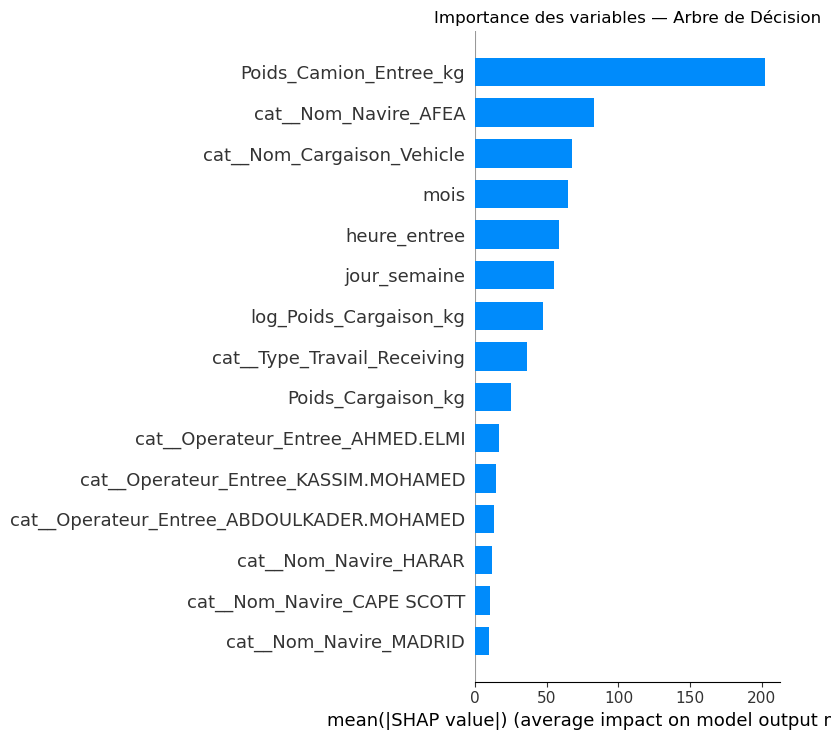

In [28]:
import pandas as pd
import shap
import matplotlib.pyplot as plt

# =========================
# Meilleur modèle retenu : Arbre + Imputation Itérative + Hyperparamétrage
# R² val. = 0.490 — RMSE val. = 607.0 min
# =========================
pipe_iter_arbre = Pipeline([
    ('comp', preprocessor_iterative),
    ('arbre', DecisionTreeRegressor(
        max_depth=grid.best_params_['arbre__max_depth'],
        min_samples_split=grid.best_params_['arbre__min_samples_split'],
        random_state=42
    ))
])

pipe_iter_arbre.fit(X_train, y_train)

print("Apprentissage")
y_pred_train = pipe_iter_arbre.predict(X_train)
qualite_reg(y_train, y_pred_train)

print("Validation")
y_pred_val = pipe_iter_arbre.predict(X_val)
qualite_reg(y_val, y_pred_val)

# =========================
# Transformation des données
# =========================
preprocess = pipe_iter_arbre.named_steps["comp"]
X_train_trans = preprocess.transform(X_train)

if hasattr(X_train_trans, "toarray"):
    X_train_trans = X_train_trans.toarray()

# Nettoyage des noms de features
feature_names_raw = preprocess.get_feature_names_out()
feature_names_clean = [
    name.replace("num_iter__", "").replace("cat__onehot__", "")
    for name in feature_names_raw
]

X_train_trans = pd.DataFrame(
    X_train_trans,
    columns=feature_names_clean,
    index=X_train.index
)

# =========================
# SHAP — Importance des variables
# =========================
model = pipe_iter_arbre.named_steps["arbre"]
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_train_trans)

shap.summary_plot(
    shap_values,
    X_train_trans,
    feature_names=X_train_trans.columns,
    plot_type="bar",
    max_display=15,
    show=False
)
plt.title("Importance des variables — Arbre de Décision")
plt.tight_layout()
plt.show()

### Conclusion 

In [ ]:
# =========================
# Conclusion Arbre de Décision
# =========================
# Meilleure imputation : Itérative + hyperparamètres
# RMSE val. = 607.0 min — R² = 0.490
# Surapprentissage massif sans tuning sur toutes les imputations :
# - Simple  : R² train = 0.970 vs R² val. = 0.363 (RMSE train=157 vs val=678.7)
# - KNN     : R² train = 0.970 vs R² val. = 0.343 (RMSE train=157 vs val=689.1)
# - Itérat. : R² train = 0.970 vs R² val. = 0.321 (RMSE train=157 vs val=700.2)
# Le tuning améliore la validation mais réduit le train :
# - Simple  : R² val. 0.363 → 0.330 après hyperparamétrage (légère dégradation)
# - KNN     : R² val. 0.343 → 0.419 après hyperparamétrage (amélioration)
# - Itérat. : R² val. 0.321 → 0.490 après hyperparamétrage (meilleure amélioration)
# → L'arbre de décision est intrinsèquement instable sur ces données :
#    il mémorise le jeu d'entraînement sans généraliser.
# → La contrainte de profondeur (max_depth, min_samples_split) réduit
#    le surapprentissage mais détériore aussi la capacité prédictive.
# → Solution : passer à la Forêt Aléatoire, qui corrige ce problème
#    en moyennant des centaines d'arbres entraînés sur des sous-échantillons
#    aléatoires, réduisant la variance sans sacrifier la précision.